In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa

In [2]:
f = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/"
run = "20251013_flex-scenarios-temporal-industry-load-27cl-3h"
scenarios = ["LowFlex", "MediumFlex", "HighFlex"]

In [3]:
networks = {}
for scenario in scenarios:
    for year in [2025, 2035, 2045]:
        fn = f"{f}/{run}/{scenario}/networks/base_s_27__none_{year}.nc"
        networks[(scenario, year)] = pypsa.Network(fn)

INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unn

In [4]:
# load variables
results = {}
for scenario in scenarios:
        df = (
        pd.read_excel(
            f"{f}/{run}/{scenario}/ariadne/exported_variables_full.xlsx",
            index_col=list(range(5)),
            # index_col=["Model", "Scenario", "Region", "Variable", "Unit"],
            sheet_name="data",
        )
        .groupby(["Variable", "Unit"], dropna=False)
        .sum()
        ).round(5)
        results[scenario] = df

In [5]:
results["LowFlex"].head()

,,2025,2035,2045
Variable,Unit,,,
Capacity Additions|Decentral Heat|Solar thermal,NaN,0.00000,0.00000,0.00000
Capacity Additions|Electricity,GW/yr,44.53674,428.00795,112.87696
Capacity Additions|Electricity|Biomass,GW/yr,0.62625,0.00045,0.00002
Capacity Additions|Electricity|Biomass|Gases and Liquids,NaN,0.00000,0.00000,0.00000
Capacity Additions|Electricity|Biomass|Solids,GW/yr,0.62625,0.00045,0.00002


In [6]:
import matplotlib.pyplot as plt

def plot_variable(variable_name, results, scenarios, unit=None):

    fig, ax = plt.subplots(figsize=(6, 4))

    for scenario in scenarios:
        data = results[scenario].loc[variable_name]

        if (unit is None) & (data.index[0] is not None):
            unit = data.index[0]
        elif unit is None:
            unit = "Unspecified unit"

        years = [int(col) for col in data.columns]
        ax.plot(years, data.values[0], marker='*', label=scenario, linewidth=2, markersize=8)
        
        # Set x-axis to show only the years in the data
        if years is not None:
            ax.set_xticks(years)
    
    ax.set_xlabel('Year')
    ax.set_ylabel(unit if unit and pd.notna(unit) else 'Value')
    ax.set_title(variable_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
# filter for vars
search = "Secondary Ener"
vars = results["LowFlex"].index.get_level_values("Variable").unique().to_list()
[v for v in vars if search in v]

['Price|Secondary Energy|Electricity',
 'Price|Secondary Energy|Gases',
 'Price|Secondary Energy|Gases|Biomass',
 'Price|Secondary Energy|Gases|Hydrogen',
 'Price|Secondary Energy|Gases|Natural Gas',
 'Price|Secondary Energy|Hydrogen',
 'Price|Secondary Energy|Hydrogen|Green',
 'Price|Secondary Energy|Liquids',
 'Price|Secondary Energy|Liquids|Hydrogen',
 'Secondary Energy',
 'Secondary Energy Input|Electricity|Heat',
 'Secondary Energy Input|Electricity|Hydrogen',
 'Secondary Energy Input|Electricity|Liquids',
 'Secondary Energy Input|Hydrogen|Electricity',
 'Secondary Energy Input|Hydrogen|Gases',
 'Secondary Energy Input|Hydrogen|Heat',
 'Secondary Energy Input|Hydrogen|Liquids',
 'Secondary Energy|Electricity',
 'Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Biomass|Gaseous and Liquid',
 'Secondary Energy|Electricity|Biomass|Solid',
 'Secondary Energy|Electricity|Biomass|w/ CCS',
 'Secondary Energy|Electricity|Biomass|w/o CCS',
 'Secondary Energy|Electricity

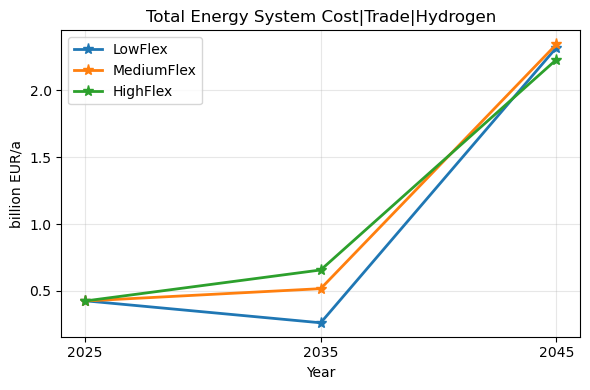

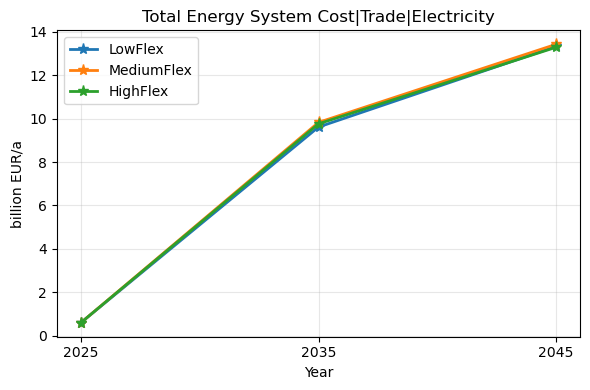

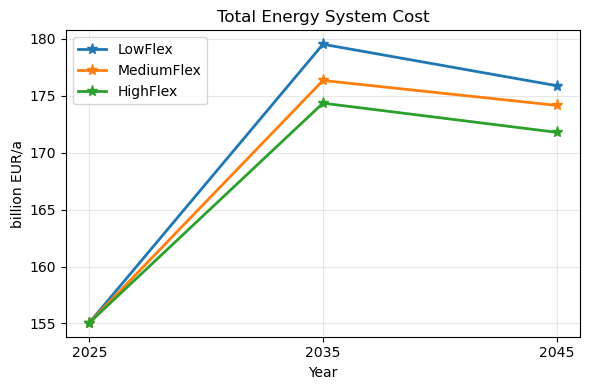

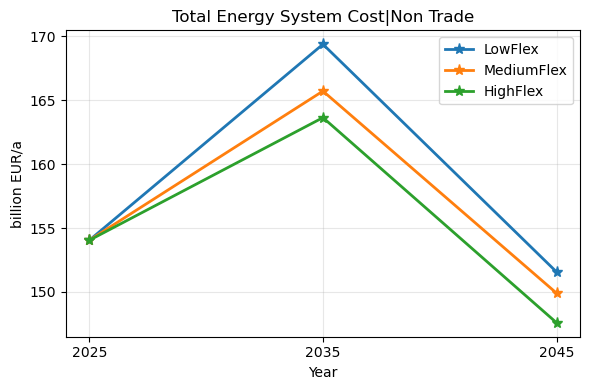

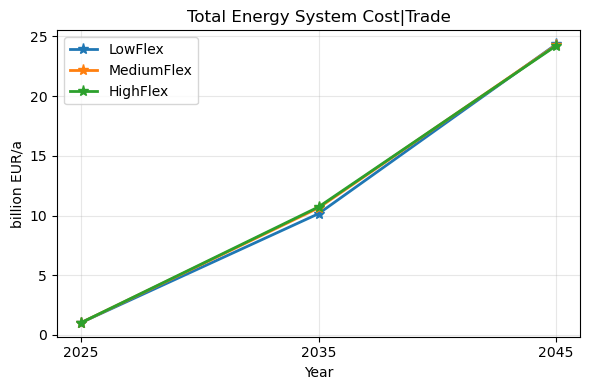

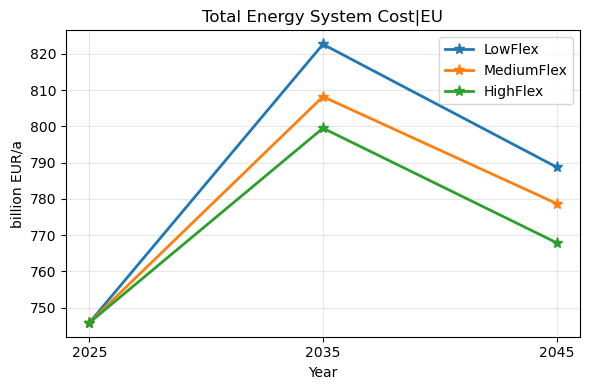

In [8]:
# System costs
plot_variable("Total Energy System Cost|Trade|Hydrogen", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Trade|Electricity", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Non Trade", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Trade", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|EU", results, scenarios, unit="billion EUR/a")


- system costs increase but not significantly
- import dependency is not clearly higher
- overall trade costs seem to be even lower for NoFlex atm (imports less hydrogen)

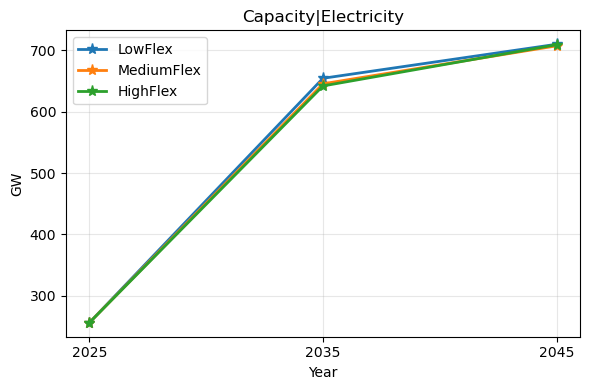

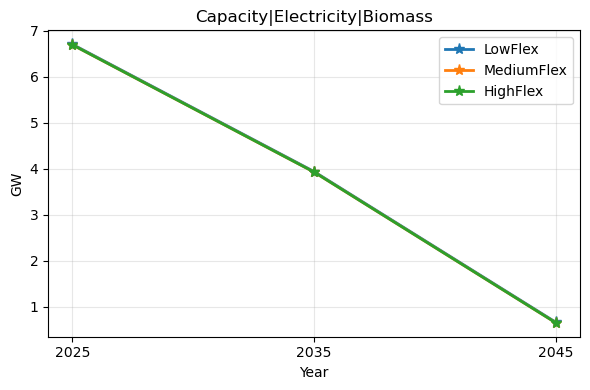

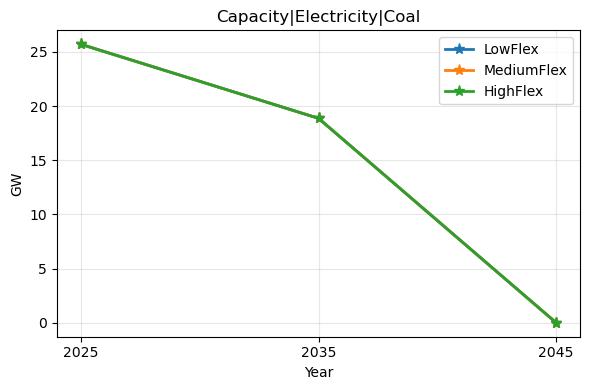

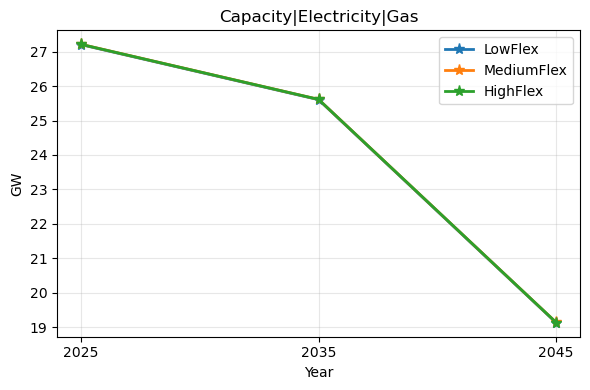

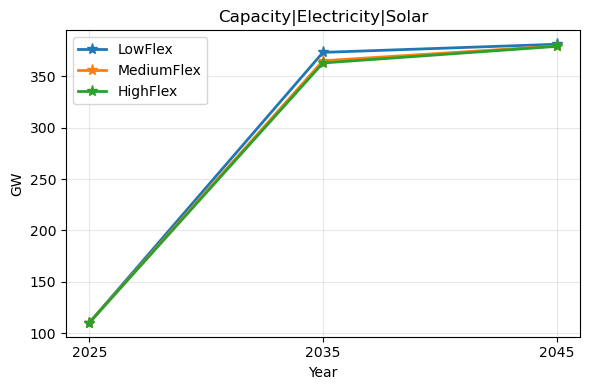

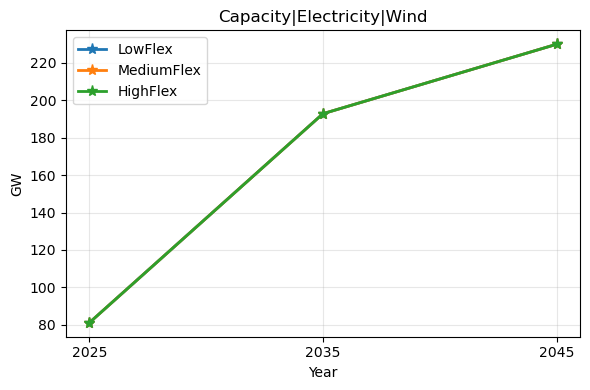

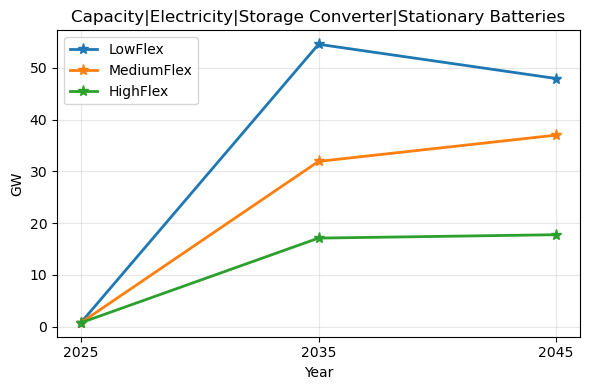

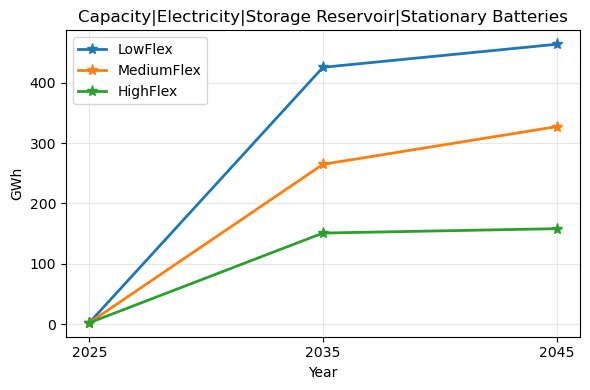

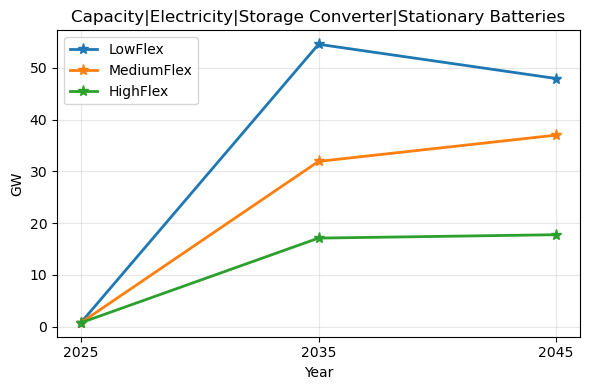

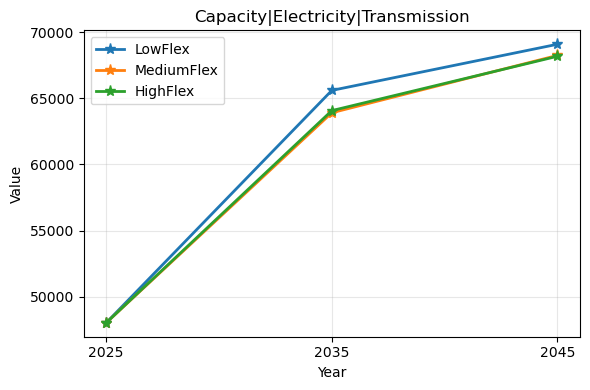

In [9]:
plot_variable("Capacity|Electricity", results, scenarios)
plot_variable("Capacity|Electricity|Biomass", results, scenarios)
plot_variable("Capacity|Electricity|Coal", results, scenarios)
plot_variable("Capacity|Electricity|Gas", results, scenarios)
plot_variable("Capacity|Electricity|Solar", results, scenarios)
plot_variable("Capacity|Electricity|Wind", results, scenarios)
plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", results, scenarios)
plot_variable("Capacity|Electricity|Storage Reservoir|Stationary Batteries", results, scenarios)
plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", results, scenarios)
plot_variable("Capacity|Electricity|Transmission", results, scenarios)



#  'Capacity|Electricity|Storage Converter',
#  'Capacity|Electricity|Storage Converter|Hydro Dam Reservoir',
#  'Capacity|Electricity|Storage Converter|Pump Hydro',
#  'Capacity|Electricity|Storage Converter|Stationary Batteries',
#  'Capacity|Electricity|Storage Converter|Vehicles',
#  'Capacity|Electricity|Storage Reservoir',
#  'Capacity|Electricity|Storage Reservoir|Hydro Dam Reservoir',
#  'Capacity|Electricity|Storage Reservoir|Pump Hydro',
#  'Capacity|Electricity|Storage Reservoir|Stationary Batteries',
#  'Capacity|Electricity|Storage Reservoir|Vehicles',
#  'Capacity|Electricity|Transmission',
#  'Capacity|Electricity|Transmission|AC',
#  'Capacity|Electricity|Transmission|AC|NEP',
#  'Capacity|Electricity|Transmission|DC',
#  'Capacity|Electricity|Transmission|DC|NEP',
#  'Capacity|Electricity|Transmission|NEP',

- capacities very similar; LowFlex has more solar
- Low Flex has highest batteries?? -> home batteries

In [10]:
kwargs = {
    "groupby": ["bus", "carrier"],
    "at_port": True,
    "nice_names": False,
}

var = pd.Series()

n = networks[("LowFlex", 2045)]

capacities_electricity = (
    n.statistics.optimal_capacity(
        bus_carrier=["AC", "low voltage"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
    .drop(
        # transmission capacities
        ["AC", "DC", "electricity distribution grid"],
        errors="ignore",
    )
)

In [11]:
capacities_electricity

carrier
BEV charger                          -442590.55501
CCGT                                    4541.80532
DAC                                       -0.02114
H2 CCGT                                    0.14108
H2 Electrolysis                       -33804.00189
H2 Fuel Cell                               0.03204
H2 OCGT                                62503.56546
H2 pipeline                              -12.83313
H2 turbine                                68.89019
OCGT                                      23.31000
PHS                                     7526.22000
battery charger                       -19741.89777
battery discharger                     19741.89777
home battery charger                  -28216.84563
home battery discharger                28216.84563
hydro                                    289.50000
methanolisation                           -0.08172
offwind-ac                              8673.53154
offwind-dc                             61326.45931
oil                    

In [ ]:
# capacities_electricity

In [23]:
from utils import tech_colors

In [31]:

tech_colors["Onshore wind"] = tech_colors["onwind"]
tech_colors["Offshore wind"] = tech_colors["offwind-ac"]
tech_colors["Solar"] = tech_colors["solar"]
tech_colors["Gas"] = tech_colors["OCGT"]
tech_colors["Gas CHP"] = tech_colors["OCGT"]
tech_colors["H2"] = tech_colors["H2 OCGT"]
tech_colors["H2 CHP"] = tech_colors["H2 OCGT"]
tech_colors["Pumped storage"] = tech_colors["PHS"]
tech_colors["Battery"] = tech_colors["battery discharger"]
tech_colors["Power-to-heat"] = tech_colors["urban central air heat pump"]
tech_colors["Electrolysis"] = tech_colors["H2 Electrolysis"]
tech_colors["Others"] = "grey"

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Carrier groupings
groups = {
    'Wind + Solar': {
        'Onshore wind': ['onwind'],
        'Offshore wind': ['offwind-ac', 'offwind-dc'],
        'Solar': ['solar', 'solar rooftop', 'solar-hsat']
    },
    'Dispatchable': {
        'Gas': ['OCGT', 'CCGT'],
        'Gas CHP': ['urban central gas CHP', 'urban central gas CHP CC'],
        'H2': ['H2 turbine', 'H2 OCGT'],
        'H2 CHP': ['H2 CCGT', 'urban central H2 CHP', 'H2 Fuel Cell'],
        'Others': ['coal', 'lignite', 'urban central coal CHP', 'urban central lignite CHP',
                   'solid biomass', 'urban central solid biomass CHP', 'urban central solid biomass CHP CC',
                   'waste CHP', 'waste CHP CC', 'oil', 'urban central oil CHP']
    },
    'Storage': {
        'Pumped storage': ['PHS'],
        'Battery': ['battery discharger', 'home battery discharger']
    },
    'Demand-side flex': {
        'Power-to-heat': ['rural air heat pump', 'rural ground heat pump', 'rural resistive heater',
                          'urban central air heat pump', 'urban central resistive heater',
                          'urban decentral air heat pump', 'urban decentral resistive heater'],
        'Electrolysis': ['H2 Electrolysis']
    }
}

def get_capacities(networks, scenarios, years):
    """Extract and group capacities for all scenarios and years"""
    kwargs = {"groupby": ["bus", "carrier"], "at_port": True, "nice_names": False}
    
    all_data = {}
    
    for scenario in scenarios:
        for year in years:
            n = networks[(scenario, year)]
            caps = (n.statistics.optimal_capacity(bus_carrier=["AC", "low voltage"], **kwargs)
                    .filter(like="DE").groupby("carrier").sum()
                    .drop(["AC", "DC", "electricity distribution grid"], errors="ignore"))
            
            # Group by technology
            grouped = {}
            for group_name, techs in groups.items():
                grouped[group_name] = {}
                for tech_name, carriers in techs.items():
                    val = caps[caps.index.isin(carriers)].sum()
                    grouped[group_name][tech_name] = abs(val) / 1000  # Convert to GW
            
            all_data[(scenario, year)] = grouped
    
    return all_data

def plot_capacity_comparison(data, scenarios, years, tech_colors):
    """Create stacked bar chart comparing scenarios across years"""
    fig, axes = plt.subplots(len(years), 4, figsize=(16, 4*len(years)), 
                             gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
    if len(years) == 1:
        axes = axes.reshape(1, -1)
    
    group_names = list(groups.keys())
    x = np.arange(len(scenarios))
    width = 0.6
    
    for year_idx, year in enumerate(years):
        for group_idx, group_name in enumerate(group_names):
            ax = axes[year_idx, group_idx]
            
            tech_names = list(groups[group_name].keys())
            bottoms = np.zeros(len(scenarios))
            
            for tech_name in tech_names:
                values = [data[(sc, year)][group_name].get(tech_name, 0) for sc in scenarios]
                
                color = tech_colors.get(tech_name, '#CCCCCC')
                hatch = '///' if 'CHP' in tech_name else None
                
                bars = ax.bar(x, values, width, bottom=bottoms, color=color, label=tech_name, 
                             hatch=hatch, edgecolor='white' if hatch else None, linewidth=0.5)
                
                # Add value labels
                for i, (bar, val) in enumerate(zip(bars, values)):
                    if val > 1:
                        ax.text(bar.get_x() + bar.get_width()/2, bottoms[i] + val/2,
                               f'{int(val)}', ha='center', va='center', fontsize=9, 
                               color='white', weight='bold')
                
                bottoms += values
            
            # Add total on top
            for i, total in enumerate(bottoms):
                if total > 0:
                    ax.text(i, total + max(bottoms)*0.02, f'{int(total)}', 
                           ha='center', va='bottom', fontsize=10, weight='bold')
            
            # Formatting
            ax.set_xticks(x)
            ax.set_xticklabels([sc[:3].lower() for sc in scenarios])
            ax.set_ylabel('Installed capacity (GW)', fontsize=10)
            ax.set_ylim(0, max(bottoms) * 1.15)
            ax.grid(axis='y', alpha=0.3)
            
            if year_idx == 0:
                ax.set_title(group_name, fontsize=12, weight='bold')
            
            if group_idx == len(group_names) - 1:
                ax.text(1.05, 0.5, str(year), transform=ax.transAxes, 
                       rotation=270, va='center', fontsize=14, weight='bold')
            
            ax.set_xlabel('Scenario', fontsize=10)
            
            # Add legend below (only for bottom row)
            if year_idx == len(years) - 1:
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(handles, labels, loc='upper center', 
                         bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=9, frameon=False)
    
    plt.tight_layout()
    return fig

/tmp/ipykernel_312670/4023615492.py:135: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



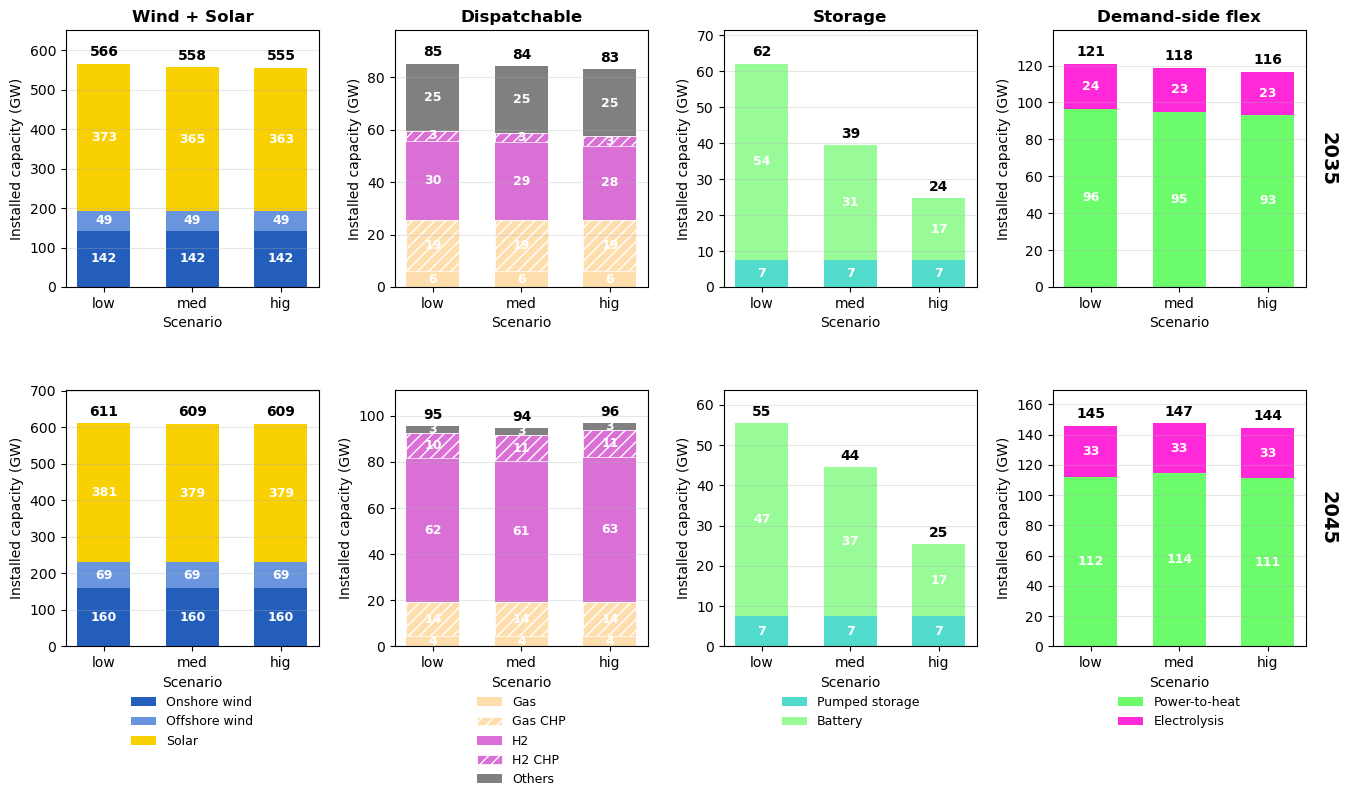

In [34]:
data = get_capacities(networks, scenarios, [2025, 2035, 2045])
fig = plot_capacity_comparison(data, scenarios, [2035, 2045], tech_colors)

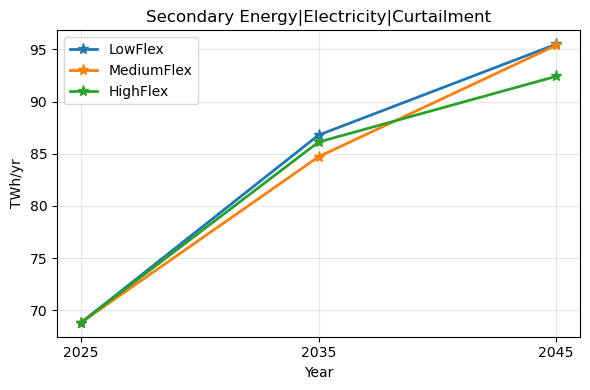

In [ ]:
plot_variable("Secondary Energy|Electricity|Curtailment", results, scenarios)

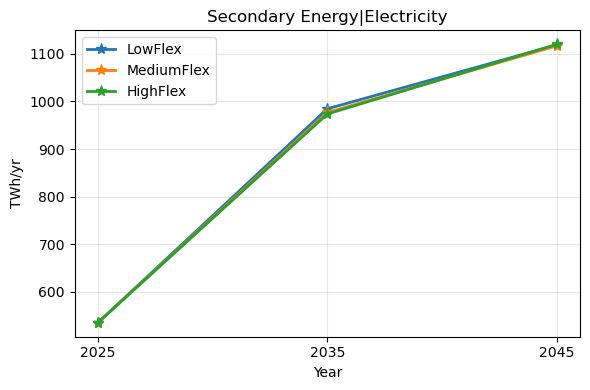

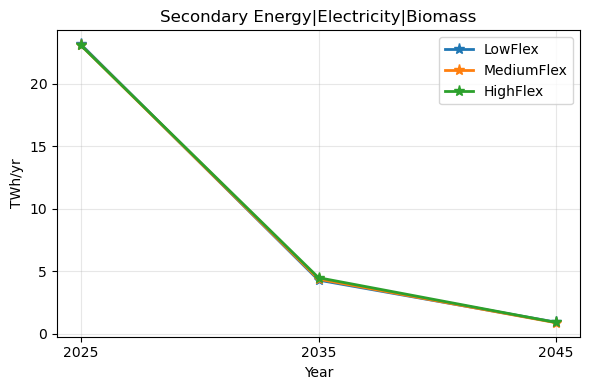

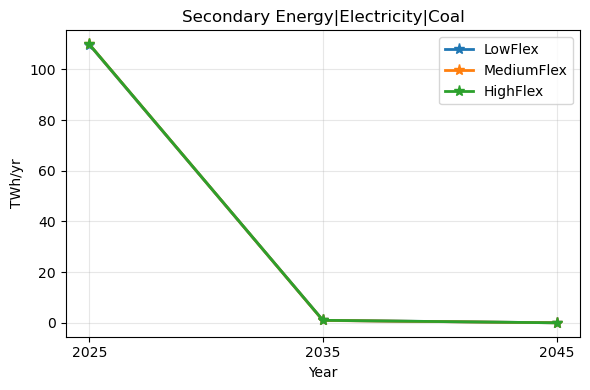

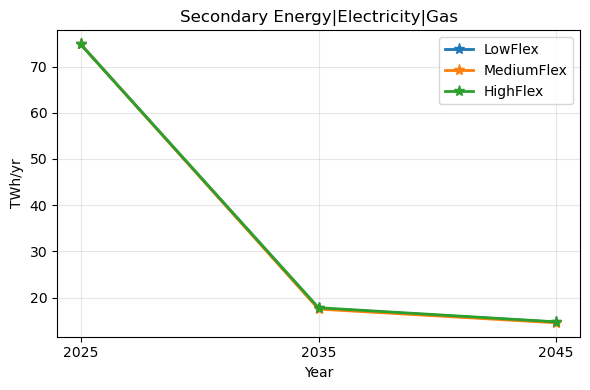

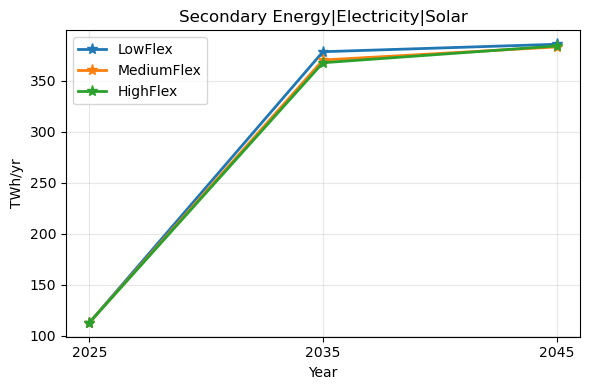

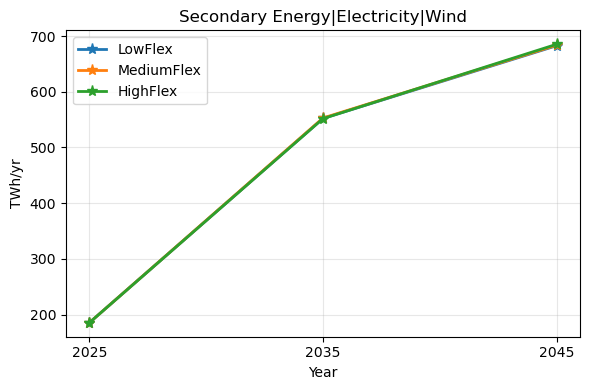

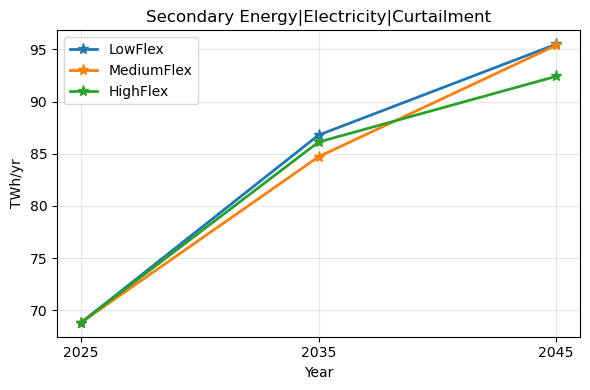

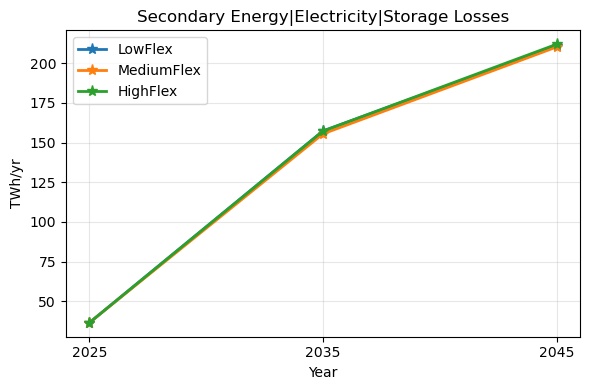

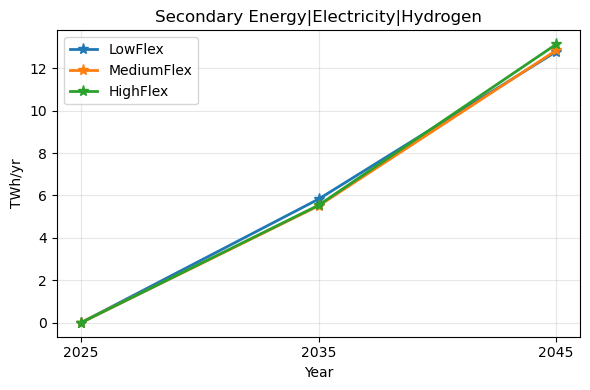

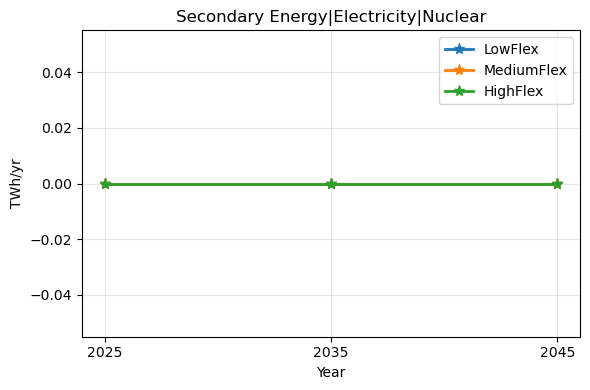

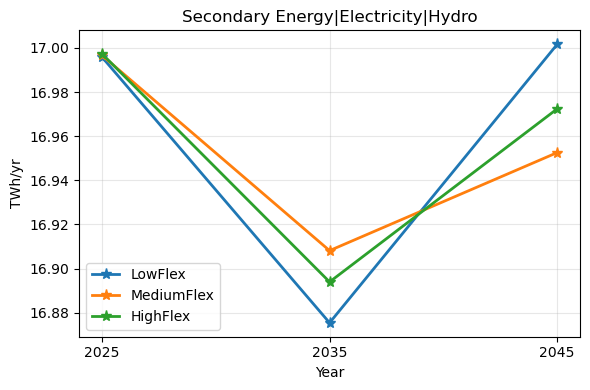

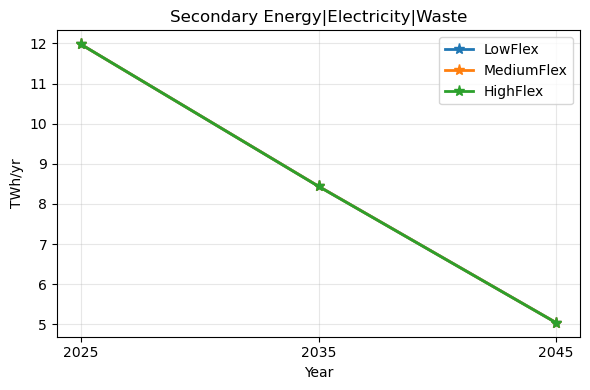

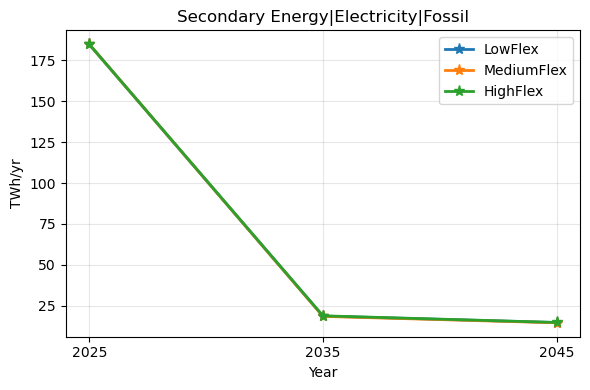

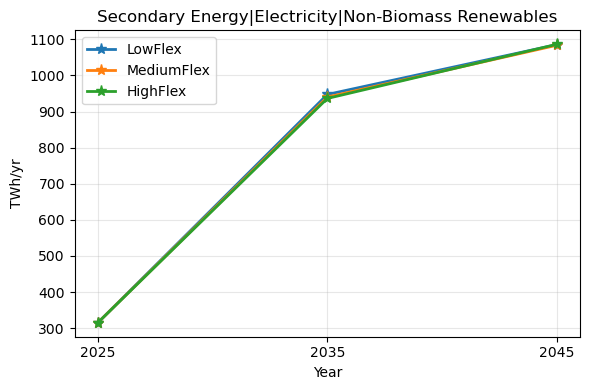

In [ ]:
# Generation
plot_variable("Secondary Energy|Electricity", results, scenarios)
plot_variable("Secondary Energy|Electricity|Biomass", results, scenarios)
plot_variable("Secondary Energy|Electricity|Coal", results, scenarios)
plot_variable("Secondary Energy|Electricity|Gas", results, scenarios)
plot_variable("Secondary Energy|Electricity|Solar", results, scenarios)
plot_variable("Secondary Energy|Electricity|Wind", results, scenarios)
plot_variable("Secondary Energy|Electricity|Curtailment", results, scenarios)
plot_variable("Secondary Energy|Electricity|Storage Losses", results, scenarios)
plot_variable("Secondary Energy|Electricity|Hydrogen", results, scenarios)
plot_variable("Secondary Energy|Electricity|Nuclear", results, scenarios)
plot_variable("Secondary Energy|Electricity|Hydro", results, scenarios)
plot_variable("Secondary Energy|Electricity|Waste", results, scenarios)
plot_variable("Secondary Energy|Electricity|Fossil", results, scenarios)
plot_variable("Secondary Energy|Electricity|Non-Biomass Renewables", results, scenarios)

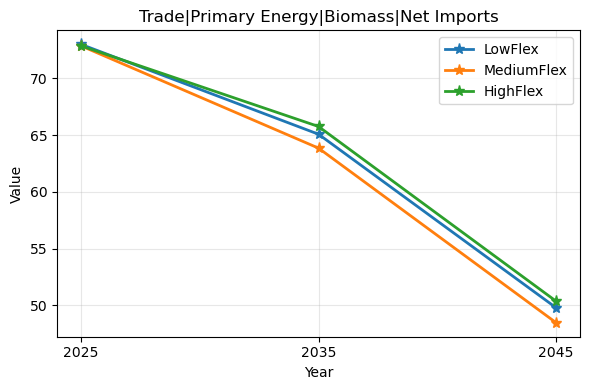

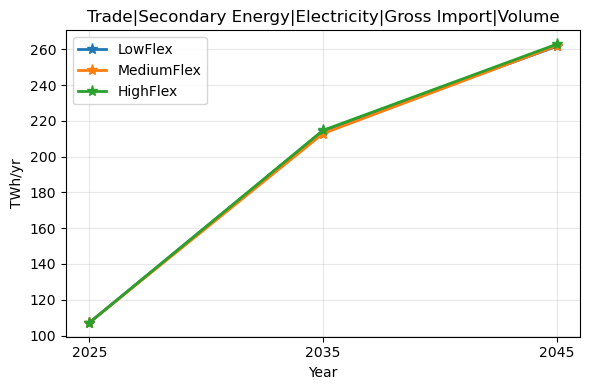

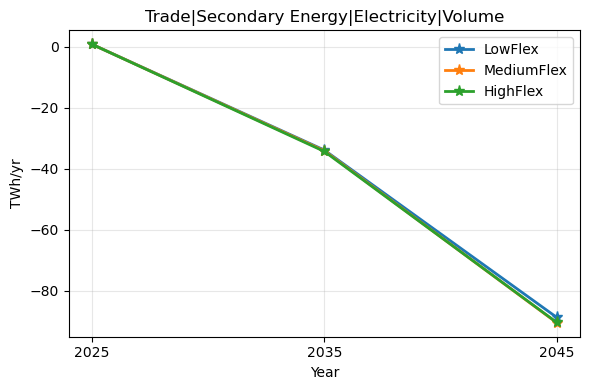

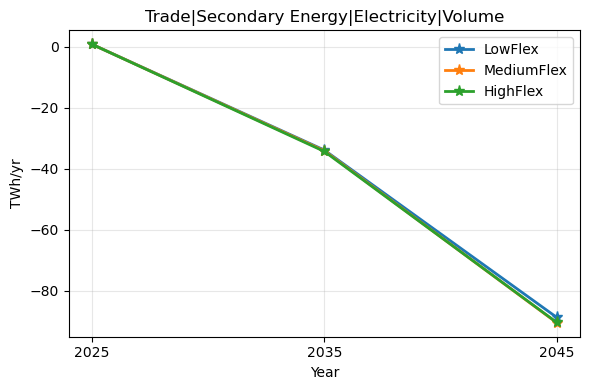

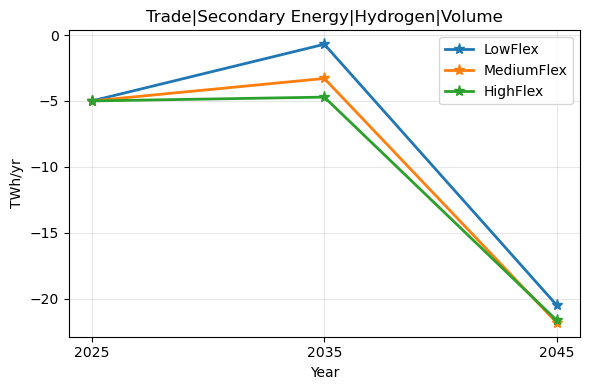

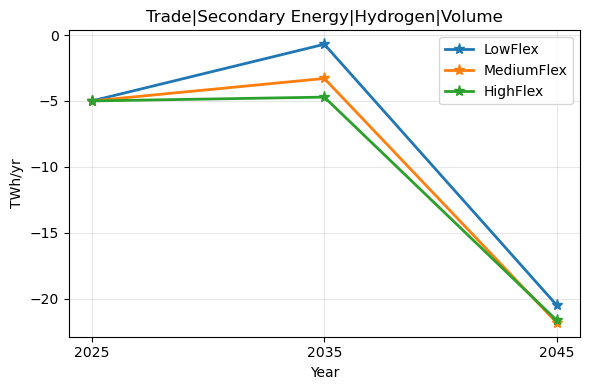

In [ ]:
# Trade
plot_variable("Trade|Primary Energy|Biomass|Net Imports", results, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Gross Import|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Hydrogen|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Hydrogen|Volume", results, scenarios)

In [ ]:
variable_name = "Total Energy System Cost|Trade|Hydrogen"
scenario = "LowFlex"
unit = "billion EUR/a"

data = results[scenario].loc[variable_name]


In [ ]:
data

,2025,2035,2045
Unit,,,
NaN,0.4259,0.26122,2.31955


In [ ]:
data.index[0]

nan

In [ ]:
if data.index[0] is not None:
    unit = data.index[0]
else:
    unit = "Unspecified unit"

In [ ]:
[int(col) for col in data.columns]

[2025, 2035, 2045]

In [ ]:
data.values[0]

array([0.4259 , 0.26122, 2.31955])